# DE-COP en BookTection — black-box, gratis (Colab)

Implementación de **DE-COP** (Duarte et al., 2024) sobre el benchmark **BookTection**
para *membership inference* en LLMs, en modo **black-box** (solo necesita la respuesta del modelo).

**Idea:** se le da al modelo una multiple-choice con el pasaje original *verbatim* + 3 paráfrasis
y se le pregunta cuál es el original. Si lo identifica consistentemente → señal de que lo vio en
el entrenamiento. Se promedia sobre permutaciones de las opciones (debiasing de posición) y se
calcula el **AUC** entre books *member* (Label=1) y *non-member* (Label=0).

Dos backends (elegís en la celda de config):
- **`groq`** → API gratis, sin GPU, OpenAI-compatible. Modelos: Llama-3.x, Gemma-2, Qwen, Mixtral.
  Ideal para tener resultados YA. ⚠️ Estos modelos tienen cutoff 2023+, así que los non-members
  de BookTection (libros 2023) están parcialmente contaminados → el AUC es un piso, no un número limpio.
- **`hf`** → corre el modelo vos en GPU (Colab T4 con tus créditos). Sirve para **Llama-2-7B**,
  que es el único temporalmente limpio para BookTection (cutoff ~sept 2022 → los libros 2023 son
  non-members reales). Llama-2 es *gated*: necesitás token de HF + aceptar la licencia.


## 1. Instalación

In [4]:
!pip install -q datasets scikit-learn pandas tqdm groq transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 2.3 MB/s eta 0:00:00


In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os, glob, shutil, json
import pandas as pd
from sklearn.metrics import roc_auc_score
OUTDIR = "/content/drive/MyDrive/decop_results"   # <- ahora vive en Drive
os.makedirs(OUTDIR, exist_ok=True)

# si todavía quedan checkpoints locales, copialos al Drive como respaldo
for f in glob.glob("decop_results/*.json"):
    shutil.copy(f, OUTDIR)
print("checkpoints en Drive:", len(os.listdir(OUTDIR)))

Mounted at /content/drive
checkpoints en Drive: 36


## 2. Configuración

Empezá chico para validar el pipeline (≈40 min, gratis con Groq), después subís los números.


In [6]:
# ----------------- CONFIG -----------------
BACKEND = "groq"          # "groq"  o  "hf"

# Modelo segun backend:
#   groq -> "llama-3.1-8b-instant" (14.4k req/dia, el mas generoso),
#           "llama-3.3-70b-versatile", "gemma2-9b-it", "qwen-2.5-32b", "mixtral-8x7b-32768"
#   hf   -> "meta-llama/Llama-2-7b-chat-hf" (gated), "mistralai/Mistral-7B-Instruct-v0.3", etc.
MODEL = "llama-3.3-70b-versatile" #"llama-3.1-8b-instant"

LENGTH = "medium"         # "small" | "medium" | "large"  (medium ~128 tokens, como en el paper)

# Sub-muestreo para un primer run rapido. Subilos despues (None = todo).
N_BOOKS_PER_CLASS   = 10  # 10 members + 10 non-members
N_PASSAGES_PER_BOOK = 10  # el dataset trae ~30 por book
N_PERMUTATIONS      = 6   # 24 = todas (paper). 6 alcanza para un primer AUC

# Rate limiting (Groq free: ~30 req/min). Subi el sleep si te tira 429.
SLEEP_BETWEEN_CALLS = 2.1  # segundos. Para 'hf' poné 0.

SEED = 2319
# ------------------------------------------

# Claves (en Colab: icono de llave 🔑 a la izquierda -> "Secrets")
import os
try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get("GROQ_API_KEY")  if BACKEND == "groq" else None
    HF_TOKEN     = userdata.get("HF_TOKEN")       if BACKEND == "hf"   else None
except Exception:
    GROQ_API_KEY = os.environ.get("GROQ_API_KEY")
    HF_TOKEN     = os.environ.get("HF_TOKEN")
print("Backend:", BACKEND, "| Modelo:", MODEL)

Backend: groq | Modelo: llama-3.3-70b-versatile


## 3. Cargar BookTection desde HuggingFace

In [7]:
import pandas as pd
from datasets import load_dataset

ds = load_dataset("avduarte333/BookTection", split="train")
df = ds.to_pandas()
df = df[df["Length"] == LENGTH].reset_index(drop=True)

# Limpiar filas rotas (#NAME? aparece en algunas celdas del CSV original)
opt_cols = ["Example_A", "Example_B", "Example_C", "Example_D"]
def ok(r): return all(isinstance(r[c], str) and r[c].strip() not in ("", "#NAME?") for c in opt_cols)
df = df[df.apply(ok, axis=1)].reset_index(drop=True)

print(f"{df['ID'].nunique()} books, {len(df)} pasajes (length={LENGTH})")
print("Members (1):", df[df.Label==1].ID.nunique(), "| Non-members (0):", df[df.Label==0].ID.nunique())
df.head(2)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/16.5k [00:00<?, ?B/s]

0_BookTection_data.csv:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16414 [00:00<?, ? examples/s]

165 books, 5494 pasajes (length=medium)
Members (1): 105 | Non-members (0): 60


,ID,Example_A,Example_B,Example_C,Example_D,Answer,Length,Label
0,1984_-_George_Orwell,"O'Brien had sat down beside the bed, so that h...",O'Brien positioned himself next to Winston's b...,O'Brien sat on the bed next to Winston so thei...,O'Brien took a seat on the bed next to Winston...,A,medium,1
1,1984_-_George_Orwell,The future belonged to the proles. And could h...,The future was owned by the proles. Winston wo...,The proles would inherit the future. Winston q...,The proles would come to rule the times ahead....,A,medium,1


## 4. Backend del modelo

`ask_model(options) -> 'A'|'B'|'C'|'D'`. Mismo prompt que el paper original.


In [ ]:
import re, time

QA_SYS = ("You are entering a multiple choice questions exam. You should directly answer "
          "each question by choosing the correct option. Be concise and straight to the point "
          "in your answer. Output only the letter corresponding to the correct answer.")

def build_prompt(options, book, author):
    q = (f'Question: Which of the following passages is verbatim from the "{book}" '
         f'book by {author}?\nOptions:\n')
    body = "".join(f"{L}. {opt}\n" for L, opt in zip("ABCD", options))
    return q + body + "Answer:"

def parse_letter(text):
    m = re.search(r"[ABCD]", (text or "").upper())
    return m.group(0) if m else "A"   # fallback

# ---------- Groq ----------
if BACKEND == "groq":
    from groq import Groq
    _client = Groq(api_key="ponerapikeyperonocommitear")
    def ask_model(options, book, author):
        prompt = build_prompt(options, book, author)
        r = _client.chat.completions.create(
            model=MODEL,
            messages=[{"role": "system", "content": QA_SYS},
                      {"role": "user",   "content": prompt}],
            max_tokens=2, temperature=0, seed=SEED)
        return parse_letter(r.choices[0].message.content)

# ---------- HuggingFace local (GPU) ----------
elif BACKEND == "hf":
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer
    _tok = AutoTokenizer.from_pretrained(MODEL, token=HF_TOKEN)
    _model = AutoModelForCausalLM.from_pretrained(
        MODEL, token=HF_TOKEN, torch_dtype=torch.float16, device_map="auto")
    def ask_model(options, book, author):
        prompt = build_prompt(options, book, author)
        msgs = [{"role": "system", "content": QA_SYS}, {"role": "user", "content": prompt}]
        try:
            ids = _tok.apply_chat_template(msgs, add_generation_prompt=True, return_tensors="pt")
        except Exception:
            ids = _tok(QA_SYS + "\n" + prompt, return_tensors="pt").input_ids
        ids = ids.to(_model.device)
        out = _model.generate(ids, max_new_tokens=2, do_sample=False,
                              pad_token_id=_tok.eos_token_id)
        return parse_letter(_tok.decode(out[0, ids.shape[1]:], skip_special_tokens=True))
else:
    raise ValueError("BACKEND debe ser 'groq' o 'hf'")

# sanity check
print(ask_model(["the cat sat", "a feline rested", "the dog ran", "birds flew"],
                "Test Book", "Test Author"))

A


## 5. Permutaciones + scoring (lógica DE-COP)

In [9]:
import itertools, random
LETTERS = ["A", "B", "C", "D"]

def make_permutations(options, n_perms, rng):
    """options[0] = original verbatim; [1..3] = parafrasis.
       Devuelve [(opciones_barajadas, letra_correcta), ...]."""
    all_perms = list(itertools.permutations(range(4)))   # 24
    rng.shuffle(all_perms)
    chosen = all_perms if (n_perms is None or n_perms >= 24) else all_perms[:n_perms]
    return [([options[i] for i in p], LETTERS[p.index(0)]) for p in chosen]

## 6. Correr DE-COP

Guarda checkpoint por book en `decop_results/` → si se corta Colab, volvés a correr y sigue.


In [10]:
# ====== CELDA 6 (reemplazo endurecido): retry + corte limpio en cap diario ======
import os, json, re, time
from tqdm.auto import tqdm

class DailyCapError(Exception): pass

def safe_ask(options, book, author, max_retries=6):
    for attempt in range(max_retries):
        try:
            return ask_model(options, book, author)
        except Exception as e:
            msg = str(e)
            if "429" not in msg and "rate_limit" not in msg.lower():
                raise
            if "per day" in msg.lower() or "TPD" in msg or "RPD" in msg:
                raise DailyCapError(msg)            # cap diario -> stop
            m2 = re.search(r"try again in (\d+)m([\d.]+)s", msg)
            m1 = re.search(r"try again in ([\d.]+)s", msg)
            wait = (int(m2.group(1))*60 + float(m2.group(2))) if m2 else (float(m1.group(1)) if m1 else 20.0)
            time.sleep(wait + 1)
    raise RuntimeError("max_retries agotado en 429 transitorio")

random.seed(SEED); rng = random.Random(SEED)
#OUTDIR = "decop_results"; os.makedirs(OUTDIR, exist_ok=True)

def pick_ids(label, k):
    ids = df[df.Label == label].ID.unique().tolist(); rng.shuffle(ids)
    return ids if k is None else ids[:k]
book_ids = pick_ids(1, N_BOOKS_PER_CLASS) + pick_ids(0, N_BOOKS_PER_CLASS)

def split_name(b):
    p = b.split("_-_"); return p[0].replace("_"," "), (p[1].replace("_"," ") if len(p)>1 else "")

results, stopped = [], False
for book_id in tqdm(book_ids, desc="books"):
    ckpt = os.path.join(OUTDIR, f"{book_id}__{MODEL.replace('/','_')}_{LENGTH}.json")
    if os.path.exists(ckpt):
        results.append(json.load(open(ckpt))); continue
    sub = df[df.ID == book_id]
    if N_PASSAGES_PER_BOOK: sub = sub.sample(min(N_PASSAGES_PER_BOOK, len(sub)), random_state=SEED)
    title, author = split_name(book_id); label = int(sub.Label.iloc[0])
    correct = total = 0
    try:
        for _, row in sub.iterrows():
            opts = [row.Example_A, row.Example_B, row.Example_C, row.Example_D]
            for shuffled, gold in make_permutations(opts, N_PERMUTATIONS, rng):
                correct += int(safe_ask(shuffled, title, author) == gold); total += 1
                if SLEEP_BETWEEN_CALLS: time.sleep(SLEEP_BETWEEN_CALLS)
    except DailyCapError:
        stopped = True
        print(f"\n⚠️ Cap diario de Groq alcanzado. Books completos: {len(results)}.")
        print("   Reanudá después de las 21:00 ARG re-corriendo esta celda; sigue desde el checkpoint.")
        break
    rec = {"book":book_id,"title":title,"label":label,"accuracy":correct/total,"n_queries":total}
    json.dump(rec, open(ckpt,"w")); results.append(rec)

res_df = pd.DataFrame(results).sort_values("label", ascending=False).reset_index(drop=True)
print(("CORTADO en cap diario. " if stopped else "COMPLETO. ") + f"{len(res_df)} books en res_df.")
res_df

books:   0%|          | 0/20 [00:00<?, ?it/s]


⚠️ Cap diario de Groq alcanzado. Books completos: 16.
   Reanudá después de las 21:00 ARG re-corriendo esta celda; sigue desde el checkpoint.
CORTADO en cap diario. 16 books en res_df.


,book,title,label,accuracy,n_queries
0,The_Adventures_of_Sherlock_Holmes_-_Sir_Arthur...,The Adventures of Sherlock Holmes,1,1.000000,60
1,Eye_Of_The_Needle_-_Ken_Follet,Eye Of The Needle,1,0.766667,60
2,Pride_And_Prejudice_-_Jane_Austen,Pride And Prejudice,1,1.000000,60
3,Hitchhiker's_Guide_To_The_Galaxy_-_Douglas_Adams,Hitchhiker's Guide To The Galaxy,1,0.950000,60
4,Harry_Potter_and_the_Prisoner_of_Azkaban_-_JK_...,Harry Potter and the Prisoner of Azkaban,1,0.933333,60
5,Name_of_the_Rose_-_Umberto_Eco,Name of the Rose,1,0.933333,60
6,And_Then_There_Were_None_-_Agatha_Christie,And Then There Were None,1,1.000000,60
7,Anne_of_Green_Gables_-_L._M._Montgomery,Anne of Green Gables,1,0.983333,60
8,1984_-_George_Orwell,1984,1,0.933333,60
9,Harry_Potter_and_the_Philosopher's_Stone_-_JK_...,Harry Potter and the Philosopher's Stone,1,0.833333,60


## 7. Resultados: AUC + curva ROC

Modelo: llama-3.1-8b-instant  |  length=medium
Accuracy media members (1)    : 0.720
Accuracy media non-members (0): 0.417
AUC (DE-COP) = 1.0000


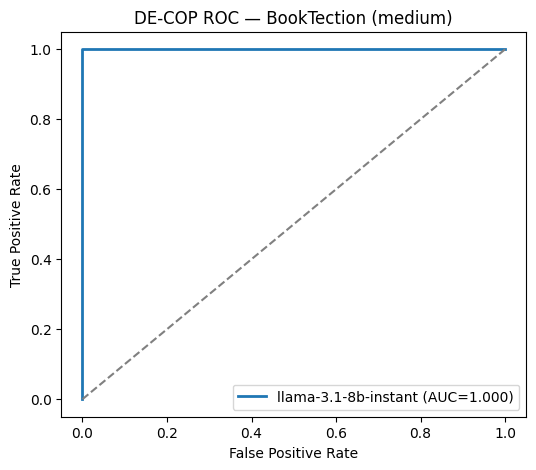

Guardado CSV.


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

y = res_df.label.values
s = res_df.accuracy.values
auc = roc_auc_score(y, s)

print(f"Modelo: {MODEL}  |  length={LENGTH}")
print(f"Accuracy media members (1)    : {s[y==1].mean():.3f}")
print(f"Accuracy media non-members (0): {s[y==0].mean():.3f}")
print(f"AUC (DE-COP) = {auc:.4f}")

fpr, tpr, _ = roc_curve(y, s)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f"{MODEL} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],"--",color="grey")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title(f"DE-COP ROC — BookTection ({LENGTH})"); plt.legend(loc="lower right")
plt.show()

res_df.to_csv(f"decop_{MODEL.replace('/','_')}_{LENGTH}.csv", index=False)
print("Guardado CSV.")

In [16]:


pat = os.path.join(OUTDIR, f"*__{MODEL.replace('/','_')}_{LENGTH}.json")
recs = [json.load(open(f)) for f in glob.glob(pat)]
res_df = pd.DataFrame(recs).sort_values("label", ascending=False).reset_index(drop=True)
n_m, n_n = (res_df.label==1).sum(), (res_df.label==0).sum()
print(f"{len(res_df)} books ({n_m} members, {n_n} non-members)")
if n_m and n_n:
    print(f"AUC preliminar = {roc_auc_score(res_df.label, res_df.accuracy):.4f}")
    print(f"acc media members={res_df.accuracy[res_df.label==1].mean():.3f} | "
          f"non={res_df.accuracy[res_df.label==0].mean():.3f}")

20 books (10 members, 10 non-members)
AUC preliminar = 1.0000
acc media members=0.720 | non=0.417


In [17]:
# 1) re-montar Drive (el restart lo desmontó) y contar lo guardado
from google.colab import drive
drive.mount('/content/drive')
import os
OUTDIR = "/content/drive/MyDrive/decop_results"
print("books en Drive:", len([f for f in os.listdir(OUTDIR) if f.endswith(".json")]))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
books en Drive: 36


In [18]:
# 2) reconstruir res_df desde Drive y calcular el AUC (cero llamadas al modelo)
import glob, json, pandas as pd
from sklearn.metrics import roc_auc_score

MODEL  = "llama-3.1-8b-instant"   # poné el modelo y length que usaste
LENGTH = "medium"

pat  = os.path.join(OUTDIR, f"*__{MODEL.replace('/','_')}_{LENGTH}.json")
recs = [json.load(open(f)) for f in glob.glob(pat)]
res_df = pd.DataFrame(recs).sort_values("label", ascending=False).reset_index(drop=True)
print(res_df)
print(f"{len(res_df)} books | members={(res_df.label==1).sum()}, non={(res_df.label==0).sum()}")
print(f"AUC = {roc_auc_score(res_df.label, res_df.accuracy):.4f}")

                                                 book  \
0   The_Adventures_of_Sherlock_Holmes_-_Sir_Arthur...   
1                      Eye_Of_The_Needle_-_Ken_Follet   
2    Hitchhiker's_Guide_To_The_Galaxy_-_Douglas_Adams   
3   Harry_Potter_and_the_Prisoner_of_Azkaban_-_JK_...   
4                   Pride_And_Prejudice_-_Jane_Austen   
5                      Name_of_the_Rose_-_Umberto_Eco   
6          And_Then_There_Were_None_-_Agatha_Christie   
7             Anne_of_Green_Gables_-_L._M._Montgomery   
8                                1984_-_George_Orwell   
9   Harry_Potter_and_the_Philosopher's_Stone_-_JK_...   
10                     The_Last_Sinner_-_Lisa_Jackson   
11                        The_Housekeepers_-_Alex_Hay   
12                 Tonight_I_Burn_-_Katharine_J_Adams   
13                We_Could_Be_So_Good_-_Cat_Sebastian   
14           A_Day_of_Fallen_Night_-_Samantha_Shannon   
15       USS_Lincoln_Mercy_Kill_-_Mark_Wayne_McGinnis   
16                    The_Only_

## Para escalar a "todos los modelos que BookTection permite"

1. Validá con la config chica de arriba (Groq, llama-3.1-8b-instant).
2. Subí `N_BOOKS_PER_CLASS=None`, `N_PASSAGES_PER_BOOK=None`, `N_PERMUTATIONS=24` para el run completo
   (ojo con el cap diario de Groq: ~14.4k req/día en el 8B; el resto 1k/día).
3. Cambiá `MODEL` y volvé a correr — cada modelo guarda su propio CSV.
   - **Groq (sin GPU):** `llama-3.3-70b-versatile`, `gemma2-9b-it`, `qwen-2.5-32b`, `mixtral-8x7b-32768`.
   - **HF en GPU (`BACKEND="hf"`, tus créditos):** `meta-llama/Llama-2-7b-chat-hf` (el limpio para
     BookTection), `mistralai/Mistral-7B-Instruct-v0.3`, `Qwen/Qwen2.5-7B-Instruct`, `google/gemma-2-9b-it`.
4. Para comparar modelos: juntá los CSV y graficá los AUC. Recordá el caveat temporal: para modelos
   con cutoff 2023+ el AUC de BookTection mezcla memorización real con contaminación de los non-members.
